In [2]:
# Requiered libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
import io
import base64


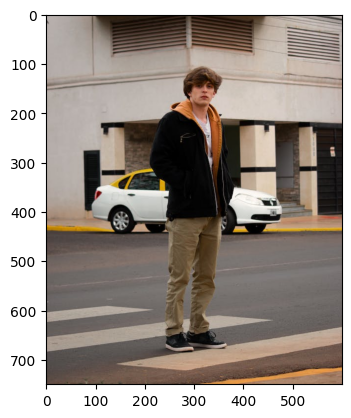

In [3]:
#Load image and convert to RGB
image = cv2.imread('data/pedestrian_day.jpg') # Load image
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB

plt.imshow(image)



In [4]:
# Use the functions from previous tasks

# TODO: Define the function to display points on an image
def show_points(coords, labels, ax, marker_size=375):
    coords = np.array(coords)
    labels = np.array(labels)
    
    # TODO Filter out the coordinates where the corresponding label is 1 (positive points)
    pos_points = coords[labels == 1]
    
    # TODO Filter out the coordinates where the corresponding label is 0 (negative points)
    neg_points = coords[labels == 0]
    
    # TODO Plot the positive points on the axes 'ax' with green color
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25
    )

    # TODO Plot the negative points on the axes 'ax' with red color
    
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25
    )


# TODO Function to display an image with points
def display_image_with_point(image, point, label):

    plt.figure(figsize=(10, 10))

    # display the image
    plt.imshow(image)

    # display the point
    show_points(point, label, plt.gca())

    # set the axes
    plt.axis("off")
    plt.show()


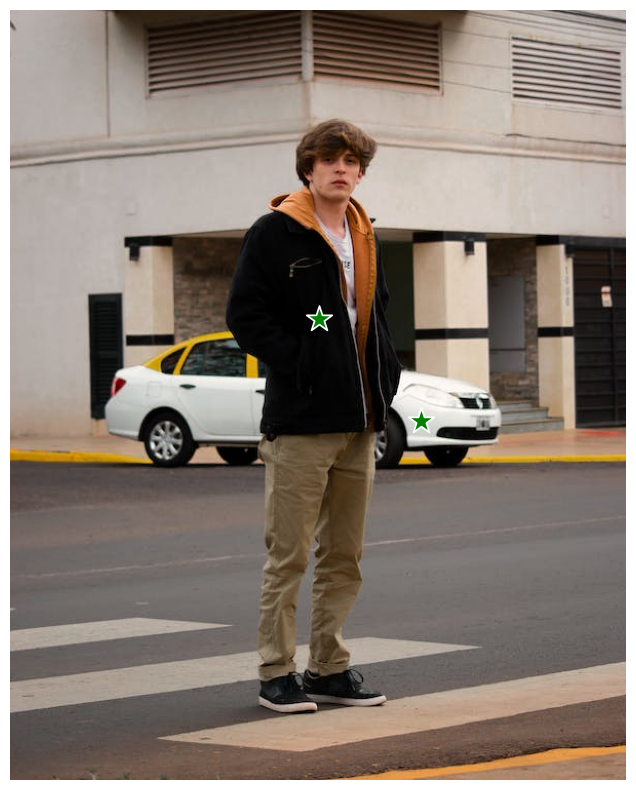

In [5]:
display_image_with_point(image, [[400, 400],[300,300]], [1,1])

In [6]:
# Use BBoxWidget to display a widget with an image
from jupyter_bbox_widget import BBoxWidget

# Create a BBoxWidget instance
widget = BBoxWidget()

# Convert the numpy array image to a PIL Image
image_pil = Image.fromarray(image)

# Create a BytesIO object
buffered = io.BytesIO()

# Save the PIL Image to the BytesIO object in JPEG format
image_pil.save(buffered, format="JPEG")

# Get the value from the BytesIO object, encode it to base64, and then decode it to string
img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')

# Set the image of the widget to the base64 encoded string
widget.image = "data:image/jpg;base64,"+img_str

widget

In [9]:

# TODO: Print the bounding boxes
print(widget.bboxes)

[{'x': 208, 'y': 108, 'width': 179, 'height': 568, 'label': ''}]


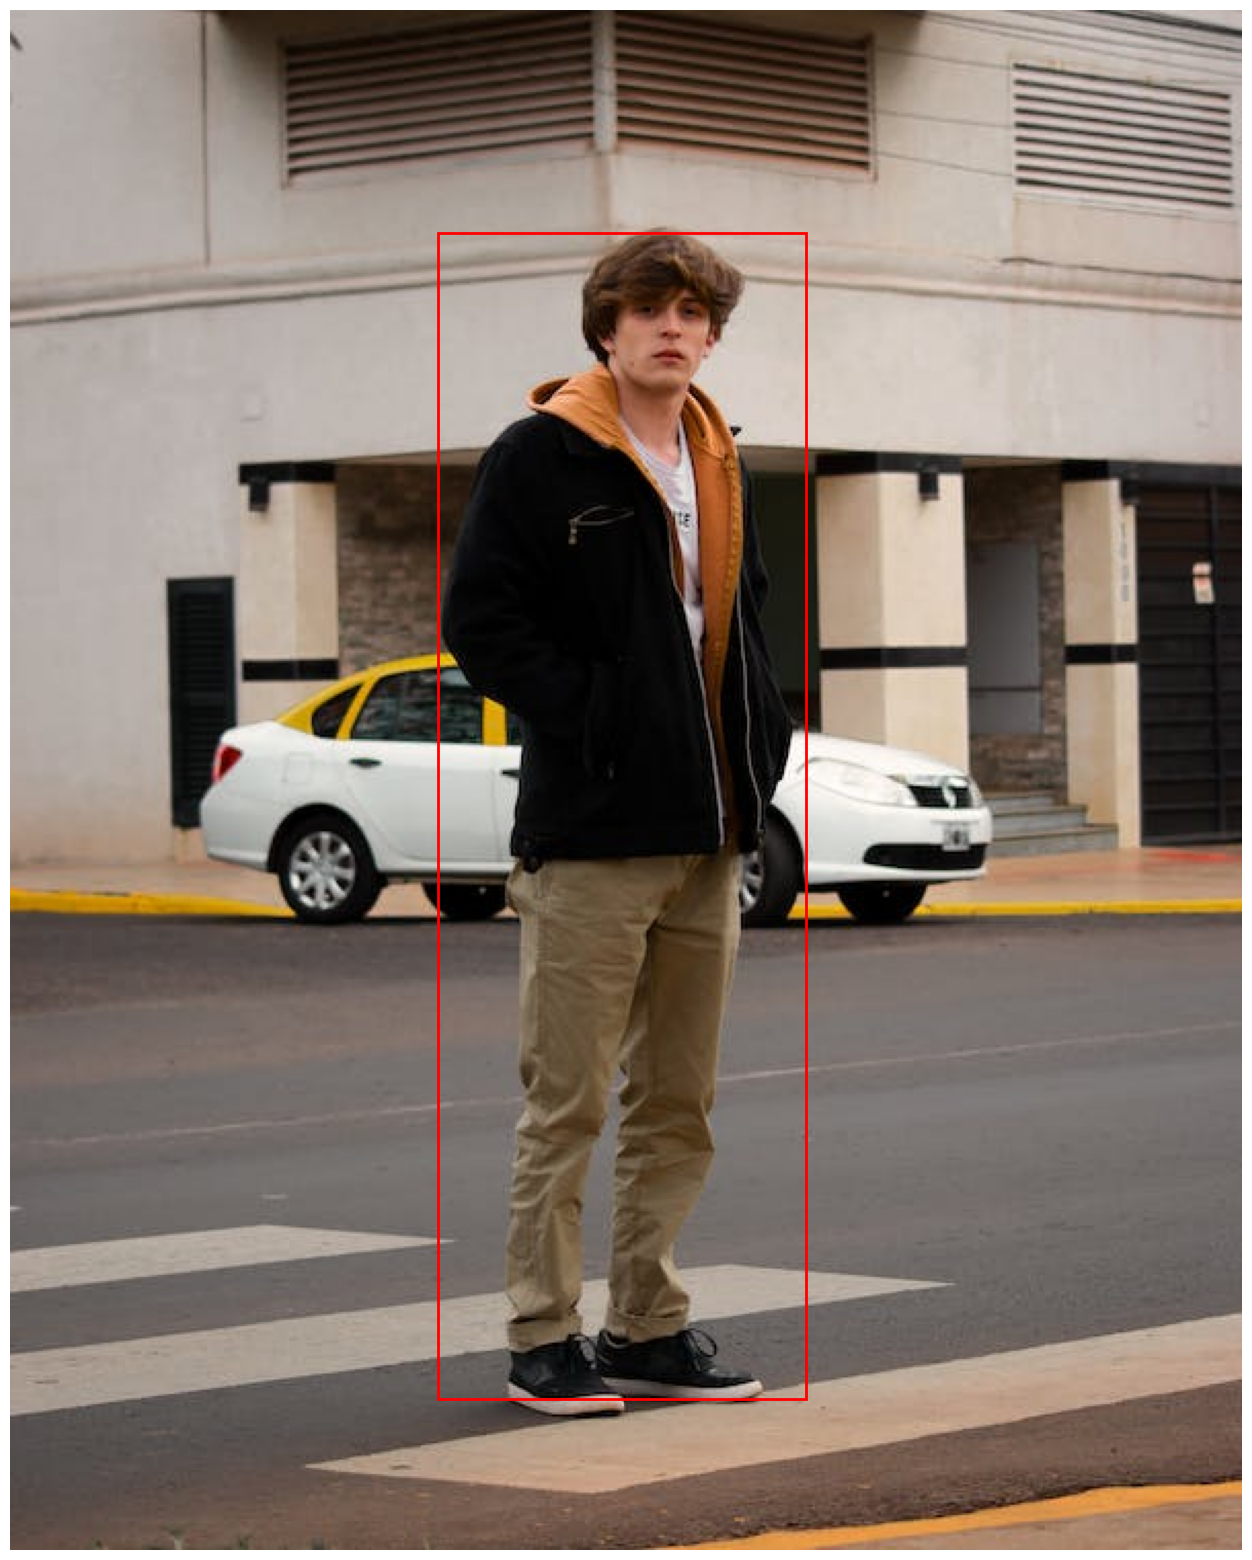

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

boxes = widget.bboxes

if boxes:
    plt.figure(figsize=(20,20))
    ax = plt.gca()

    # Display image
    ax.imshow(image)

    # Display boxes
    for box in boxes:
        rect = patches.Rectangle(
            (box["x"], box["y"]),
            box["width"],
            box["height"],
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

    plt.axis("off")
    plt.show()

else:
    print("No bounding boxes to display.")